# Data Analysis of Instance Generation

In [1]:
from bargain import read_h5
from bargain.tests import tests_gain_net

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style = "ticks")
palette = 'viridis'

In [2]:
path = "instances.h5"
datasets = ['instance', 'gain', 'shapley', 'nucleolus', 'coalitions']
data = read_h5(path, datasets)

Let's have a look at the characteristic function.

Text(0.5, 1.0, 'Characteristic function')

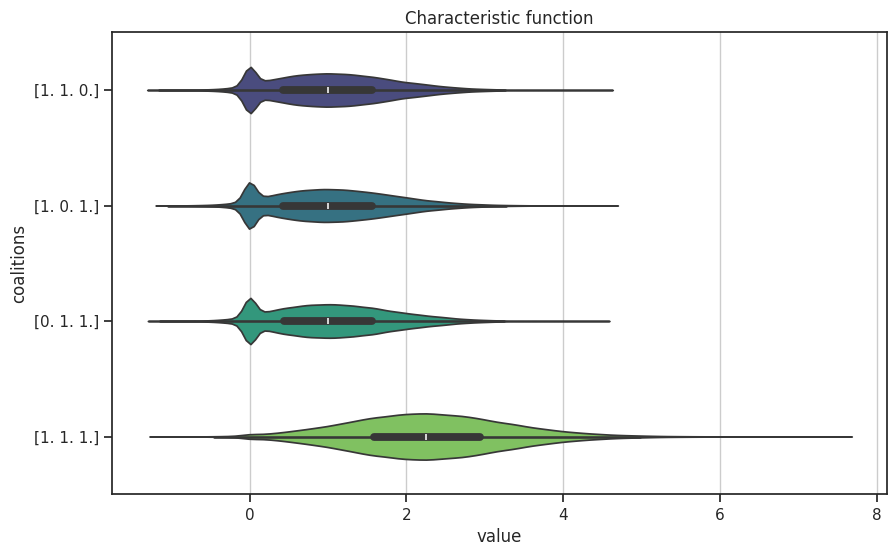

In [3]:
char_function = data['gain']
coalitions = data['coalitions']
char_dict = {}

for i, coalition in enumerate(coalitions[0]):
    char_dict[str(coalition)] = char_function[:, i]

char_pd = pd.DataFrame(char_dict)
char_pd = char_pd.melt(var_name = 'coalitions', value_name = 'value')

f, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data = char_pd, x = 'value', y = 'coalitions', hue = 'coalitions',
            width = .4, palette = palette)
ax.xaxis.grid(True)
ax.set_title('Characteristic function')

<Axes: ylabel='Count'>

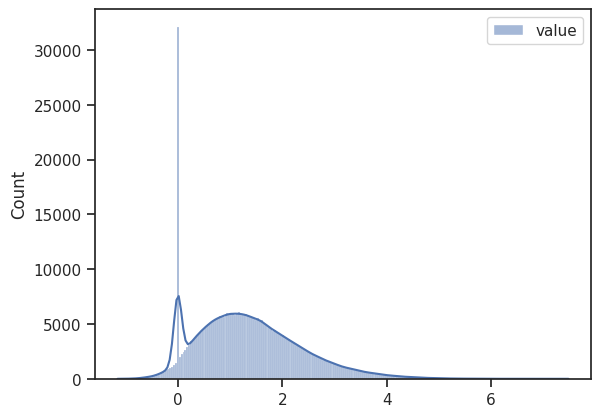

In [4]:
sns.histplot(char_pd, kde = True)

Text(0.5, 1.0, 'Shapley value')

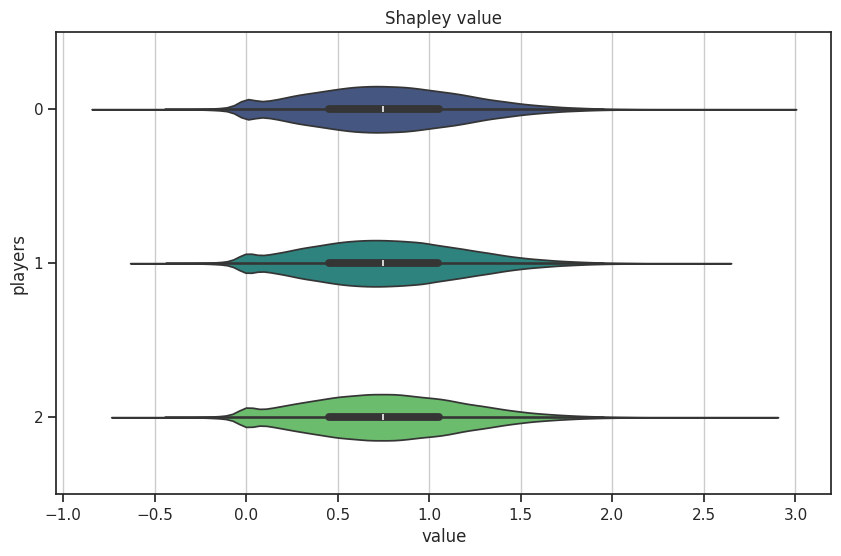

In [5]:
n_players = 3
shap = data['shapley']
shap_dict = {}

for player_id in range(n_players):
    shap_dict[str(player_id)] = shap[:, player_id]

shap_pd = pd.DataFrame(shap_dict)
shap_pd = shap_pd.melt(var_name = 'players', value_name = 'value')

f, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data = shap_pd, x = 'value', y = 'players', hue = 'players',
            width = .3, palette = palette)
ax.xaxis.grid(True)
ax.set_title('Shapley value')

Text(0.5, 1.0, 'Nucleolus')

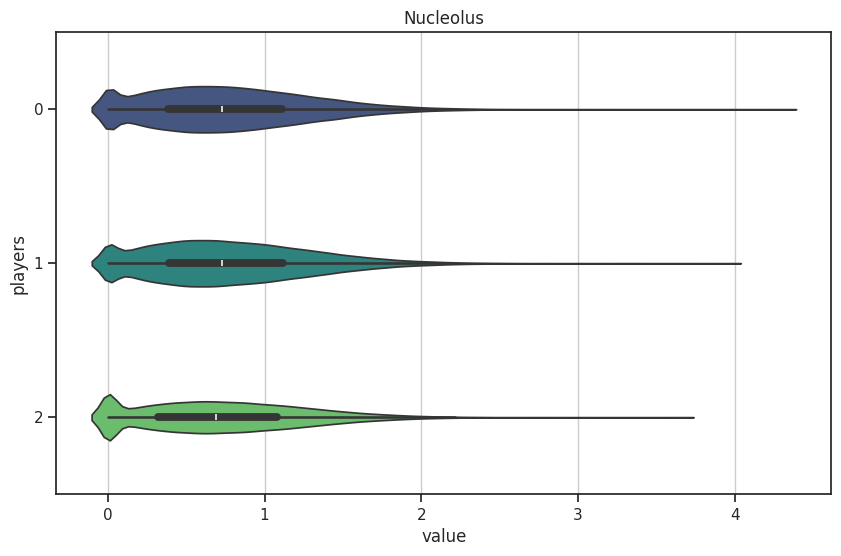

In [6]:
n_players = 3
nucl = data['nucleolus']
nucl_dict = {}

for player_id in range(n_players):
    nucl_dict[str(player_id)] = nucl[:, player_id]

nucl_pd = pd.DataFrame(nucl_dict)
nucl_pd = nucl_pd.melt(var_name = 'players', value_name = 'value')

f, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data = nucl_pd, x = 'value', y = 'players', hue = 'players',
            width = .3, palette = palette)
ax.xaxis.grid(True)
ax.set_title('Nucleolus')

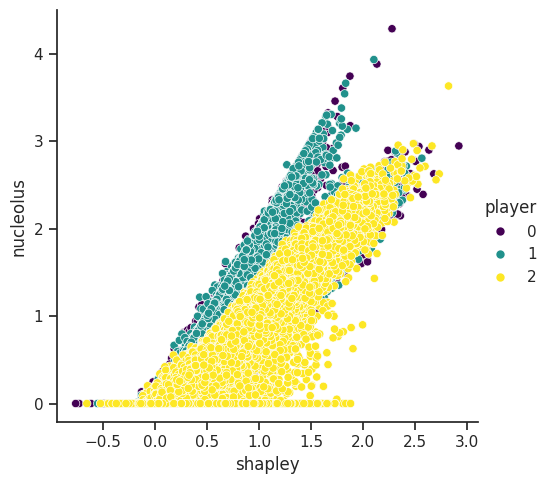

In [7]:
sol_dict = {'shapley': [], 'nucleolus': [], 'player': []}
players = range(n_players)
for i in players:
    sol_dict['shapley'] = sol_dict['shapley'] + list(shap_dict[str(i)])
    sol_dict['nucleolus'] = sol_dict['nucleolus'] + list(nucl_dict[str(i)])
    sol_dict['player'] = sol_dict['player'] + [i] * len(nucl_dict[str(i)])

sol_pd = pd.DataFrame(sol_dict)
g = sns.relplot(data = sol_pd, x = 'shapley', y = 'nucleolus', hue = 'player',
                palette = palette, sizes = (10, 200))

Text(0.5, 1.0, 'GainNN')

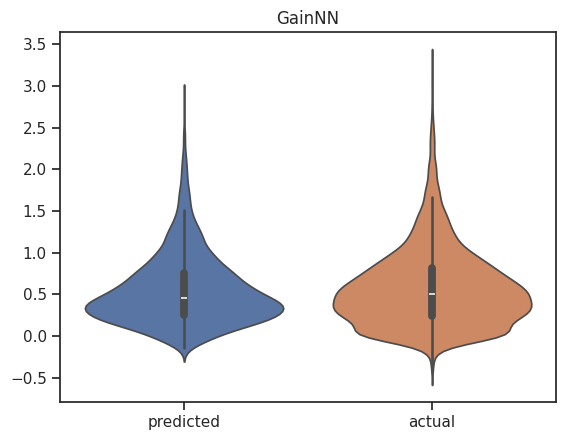

In [8]:
seed = None
values, gains = tests_gain_net(path = 'models/GainNN.pth',
                               n_tests = 1000,
                               seed = seed)

sns.violinplot(data = {'predicted': values, 'actual': gains})
plt.title("GainNN")

<Axes: ylabel='Count'>

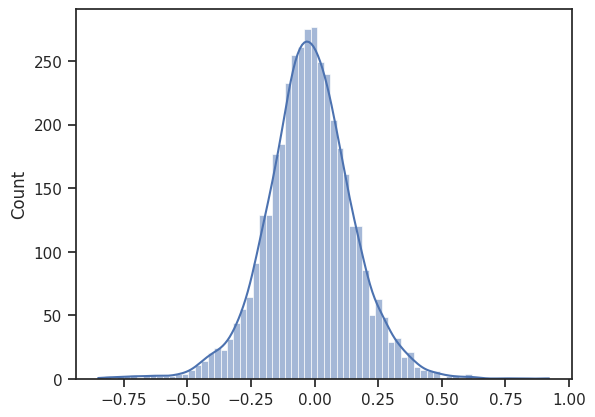

In [9]:
sns.histplot(data = values - gains, kde = True)

Text(0.5, 1.0, 'GainNN Performance')

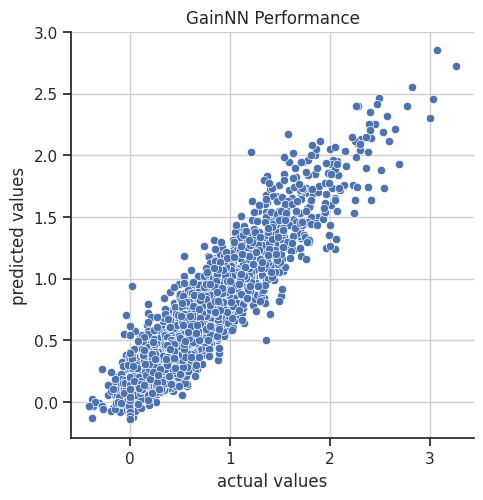

In [11]:
sns.relplot(x = gains, y = values); plt.grid(True)
plt.xlabel('actual values'); plt.ylabel('predicted values')
plt.title("GainNN Performance")